# Modelos

Cargar datos

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/housing_clean_2.csv')
df1 = pd.read_csv('../data/housing_grupo1.csv')
df2 = pd.read_csv('../data/housing_grupo2.csv')
df3 = pd.read_csv('../data/housing_grupo3.csv')

## XGBoost

In [ ]:
from sklearn.model_selection import train_test_split

# Definir las variables predictoras X y la variable objetivo y
X = df[['surface', 'bedrooms', 'restrooms', 'Terraza', 'Ascensor', 'Piscina', 'Calefacción']]
y = df['price']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=12)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Modelo base
xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',      # rápido y estable
    # tree_method='gpu_hist',
    eval_metric='rmse',
    random_state=42
)

# Espacio de búsqueda
param_dist = {
    'n_estimators': randint(200, 2200),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 12),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2)
}

# RandomizedSearch
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                # suficiente para converger
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search.fit(X_train, y_train)

print('Mejores parámetros:')
print(random_search.best_params_)

print('Mejor MSE CV:')
print(-random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores parámetros:
{'colsample_bytree': 0.8497561053835969, 'gamma': 0.6917654620890068, 'learning_rate': 0.04982362667289095, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 856, 'reg_alpha': 0.39882090144479454, 'reg_lambda': 1.367041475161484, 'subsample': 0.8720213214995577}
Mejor MSE CV:
269559.50625


In [27]:
# Entrenamos modelo con mejores parámetros
best_params = random_search.best_params_

final_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    random_state=42,
    **best_params
)

final_model.fit(X_train, y_train)

predictions = final_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, predictions))
print('MAPE:', mean_absolute_percentage_error(y_test, predictions))
print('MSE:', mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions)))
print('r2_score train', final_model.score(X_train, y_train))
print('r2_score test',final_model.score(X_test, y_test))

MAE: 350.9979248046875
MAPE: 0.4238545000553131
MSE: 267017.59375
RMSE: 516.7374514683448
r2_score train 0.33506959676742554
r2_score test 0.29809701442718506


In [28]:
# Guardar el modelo en un archivo con pickle

import pickle

# Guardar el modelo entrenado en un archivo
with open('../api/models/modelo_xgb_v1.pkl', 'wb') as file:
    pickle.dump(final_model, file)

Modelos por grupos

In [35]:
# Definir las variables predictoras X y la variable objetivo y
X1 = df1[['surface', 'bedrooms', 'restrooms', 'Terraza', 'Ascensor', 'Piscina', 'Calefacción']]
y1 = df1['price']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [38]:
# Entrenamos modelo con mejores parámetros
best_params = random_search.best_params_

final_model1 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    random_state=42,
    **best_params
)

final_model1.fit(X_train1, y_train1)

predictions1 = final_model1.predict(X_test1)

print('MAE:', mean_absolute_error(y_test1, predictions1))
print('MAPE:', mean_absolute_percentage_error(y_test1, predictions1))
print('MSE:', mean_squared_error(y_test1, predictions1))
print('RMSE:', np.sqrt(mean_squared_error(y_test1, predictions1)))
print('r2_score train', final_model.score(X_train1, y_train1))
print('r2_score test',final_model.score(X_test1, y_test1))

MAE: 153.78421020507812
MAPE: 0.2678254246711731
MSE: 84013.015625
RMSE: 289.8499881404172
r2_score train 0.302870512008667
r2_score test 0.1534113883972168


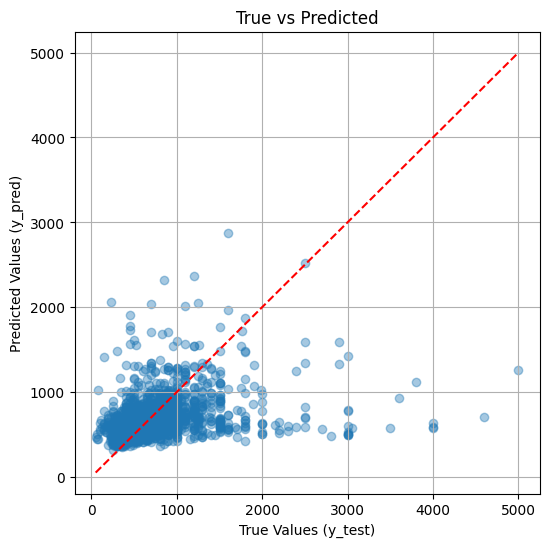

In [45]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test1, predictions1, alpha=0.4)

# Perfect prediction line
min_val = min(y_test1.min(), predictions1.min())
max_val = max(y_test1.max(), predictions1.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("True vs Predicted")
plt.grid(True)

plt.show()

In [48]:
# Guardar el modelo en un archivo con pickle

import pickle

# Guardar el modelo entrenado en un archivo
with open('../api/models/modelo_xgb_g1.pkl', 'wb') as file:
    pickle.dump(final_model1, file)

In [41]:
# Definir las variables predictoras X y la variable objetivo y
X2 = df2[['surface', 'bedrooms', 'restrooms', 'Terraza', 'Ascensor', 'Piscina', 'Calefacción']]
y2 = df2['price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [42]:
# Entrenamos modelo con mejores parámetros
best_params = random_search.best_params_

final_model2 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    random_state=42,
    **best_params
)

final_model2.fit(X_train2, y_train2)

predictions2 = final_model2.predict(X_test2)

print('MAE:', mean_absolute_error(y_test2, predictions2))
print('MAPE:', mean_absolute_percentage_error(y_test2, predictions2))
print('MSE:', mean_squared_error(y_test2, predictions2))
print('RMSE:', np.sqrt(mean_squared_error(y_test2, predictions2)))
print('r2_score train', final_model2.score(X_train2, y_train2))
print('r2_score test',final_model2.score(X_test2, y_test2))

MAE: 220.8773651123047
MAPE: 0.30050307512283325
MSE: 140845.703125
RMSE: 375.2941554634178
r2_score train 0.4135271906852722
r2_score test 0.32968980073928833


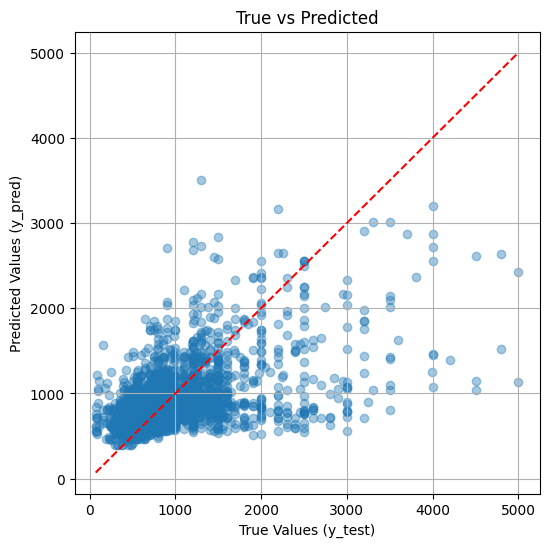

In [46]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test2, predictions2, alpha=0.4)

# Perfect prediction line
min_val = min(y_test2.min(), predictions2.min())
max_val = max(y_test2.max(), predictions2.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("True vs Predicted")
plt.grid(True)

plt.show()

In [49]:
# Guardar el modelo en un archivo con pickle

import pickle

# Guardar el modelo entrenado en un archivo
with open('../api/models/modelo_xgb_g2.pkl', 'wb') as file:
    pickle.dump(final_model2, file)

In [43]:
# Definir las variables predictoras X y la variable objetivo y
X3 = df3[['surface', 'bedrooms', 'restrooms', 'Terraza', 'Ascensor', 'Piscina', 'Calefacción']]
y3 = df3['price']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [44]:
# Entrenamos modelo con mejores parámetros
best_params = random_search.best_params_

final_model3 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    random_state=42,
    **best_params
)

final_model3.fit(X_train3, y_train3)

predictions3 = final_model3.predict(X_test3)

print('MAE:', mean_absolute_error(y_test3, predictions3))
print('MAPE:', mean_absolute_percentage_error(y_test3, predictions3))
print('MSE:', mean_squared_error(y_test3, predictions3))
print('RMSE:', np.sqrt(mean_squared_error(y_test3, predictions3)))
print('r2_score train', final_model3.score(X_train3, y_train3))
print('r2_score test',final_model3.score(X_test3, y_test3))

MAE: 387.8750915527344
MAPE: 0.33217427134513855
MSE: 315727.9375
RMSE: 561.8967320602603
r2_score train 0.41113752126693726
r2_score test 0.3850504159927368


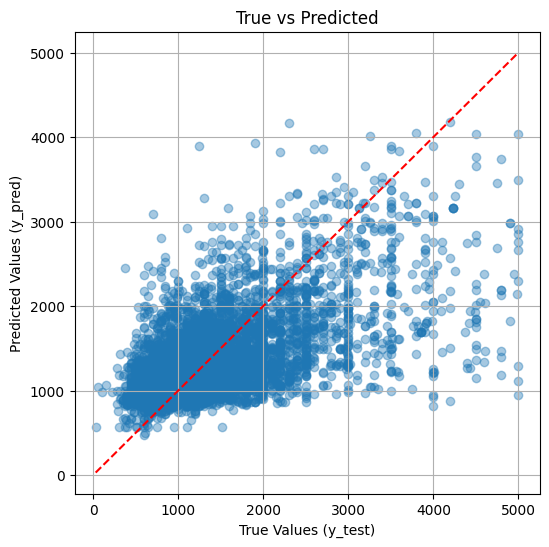

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test3, predictions3, alpha=0.4)

# Perfect prediction line
min_val = min(y_test3.min(), predictions3.min())
max_val = max(y_test3.max(), predictions3.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("True vs Predicted")
plt.grid(True)

plt.show()

In [50]:
# Guardar el modelo en un archivo con pickle

import pickle

# Guardar el modelo entrenado en un archivo
with open('../api/models/modelo_xgb_g3.pkl', 'wb') as file:
    pickle.dump(final_model3, file)